# Factor panels: IC, quantiles, turnover

Recipe 02/05 builds a factor and scores it with pandas and scipy. That is the
right way to learn what an information coefficient is, and the wrong way to
run a factor library: every desk that does it ends up with three
implementations of the same rank correlation and no agreement about which is
authoritative.

`quant.build_panel` is the shared implementation. It joins a factor to forward
returns, assigns quantiles, and exposes the whole `alphalens` surface -- IC,
decay, quantile returns, spreads, turnover, factor-portfolio alpha -- as
queries against the engine. The panel is a pinned query rather than a frame,
so the numbers carry the data version they came from and a hundred thousand
rows never leave the database.

## Terms used here

| term                | meaning |
| ------------------- | --- |
| factor              | a number per asset per date that is supposed to predict returns |
| forward return      | the return over the next *n* bars, the thing a factor is scored against |
| information coefficient | the rank correlation between the factor and the return that followed |
| quantile bucket     | assets split into equal-count groups by factor value each date |
| spread              | the return of the top bucket minus the bottom one |
| turnover            | how much of a bucket's membership changes from one date to the next |
| rank autocorrelation| how stable an asset's factor rank is over time |
| group neutral       | comparing assets only against others in their own sector |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import h5i_db
from h5i_db import col, quant, sql_expr
import cookbook_utils as cu

## 1. Prices and a factor, both long

Both inputs are long format: `(ts, asset, value)`. Here the factor is 12-1
momentum and the price is the adjusted close, and both come from one table.

In [2]:
daily = cu.fetch_daily(cu.SP500_EXAMPLES, start="2018-01-01", end="2026-07-01")
db = h5i_db.Database(cu.fresh_db("06_factor_panels_and_reports"), create=True)
prices = daily.sort_by([("ts", "ascending"), ("symbol", "ascending")])
db.create_table("prices", prices.schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("prices", prices, note="30 large caps, 2018-2026")
db.snapshot("prices-v1", tables=["prices"], note="The cut the panel is pinned to")
print(f"{prices.num_rows:,} rows, {daily.to_pandas()['symbol'].nunique()} names")
daily.to_pandas().head(3)

64,020 rows, 30 names


,ts,symbol,open,high,low,close,adj_close,volume
0,2018-01-02 20:00:00+00:00,AAPL,42.540001,43.075001,42.314999,43.064999,40.267075,102223600
1,2018-01-02 20:00:00+00:00,NVDA,4.894500,4.987500,4.862500,4.983750,4.922529,355616000
2,2018-01-02 20:00:00+00:00,GE,84.251045,86.215950,84.011429,86.168022,80.953125,16185981


A lazy frame passed to `build_panel` is taken as given, which means **the pin
has to be on the frame**. `db.table(name, snapshot=...)` puts it there. Passing
an unpinned frame together with `snapshot=` would produce a panel that claims
a pin in its provenance and reads the latest version anyway.

In [3]:
pinned = db.table("prices", snapshot="prices-v1")
price_frame = pinned.select(ts=col("ts"), asset=col("symbol"), price=col("adj_close"))
factor_frame = (
    pinned.with_columns(
        month_ago=sql_expr("lag(adj_close, 21)").over(partition_by="symbol", order_by="ts"),
        year_ago=sql_expr("lag(adj_close, 252)").over(partition_by="symbol", order_by="ts"),
    )
    .with_columns(momentum=col("month_ago") / col("year_ago") - 1)
    .select(ts=col("ts"), asset=col("symbol"), factor=col("momentum"))
)
print(factor_frame.sql())

SELECT "ts" AS "ts", "symbol" AS "asset", "momentum" AS "factor"
FROM (
  SELECT *, "month_ago" / "year_ago" - 1 AS "momentum"
  FROM (
    SELECT *, lag(adj_close, 21) OVER (PARTITION BY "symbol" ORDER BY "ts") AS "month_ago", lag(adj_close, 252) OVER (PARTITION BY "symbol" ORDER BY "ts") AS "year_ago"
    FROM h5i('prices', 'prices-v1')
  ) AS "_s1"
) AS "_s2"


## 2. The panel

`periods` are forward-return horizons in bars, so on daily data these are one
day, one week and one month. `quantiles=5` splits each date into five
equal-count buckets. `filter_zscore` drops factor values more than twenty
standard deviations from the mean, which is a data-error filter rather than a
modelling choice.

In [4]:
panel = quant.build_panel(
    db,
    factor_frame,
    price_frame,
    periods=(1, 5, 21),
    quantiles=5,
    filter_zscore=20.0,
    max_loss=0.35,
)
print(panel)
panel.collect().to_pandas().head()

FactorPanel(periods=[1, 5, 21], group=False, digest=825d19a73687)


,ts,asset,factor,fwd_1,fwd_5,fwd_21,factor_quantile
0,2019-01-03 20:00:00+00:00,GE,-0.571640,0.021092,0.109182,0.266750,1
1,2019-01-03 20:00:00+00:00,GS,-0.243882,0.032682,0.038287,0.166421,1
2,2019-01-03 20:00:00+00:00,META,-0.224948,0.047138,0.094580,0.284727,1
3,2019-01-03 20:00:00+00:00,NVDA,-0.177898,0.064068,0.134698,0.165560,1
4,2019-01-03 20:00:00+00:00,IBM,-0.157919,0.039058,0.078647,0.197325,1


## 3. What the panel threw away

`loss_report` is the accounting `alphalens` prints and most users skip. Rows
are lost joining to forward returns (no price far enough ahead, a non-finite
factor value) and lost again in binning. `max_loss` refuses the panel outright
when too much of the factor never made it, because a factor scored on the
surviving 40% of its own values is a different factor.

In [5]:
report = panel.loss_report()
print(f"factor rows          {report['initial']:,}")
print(f"after forward returns{report['after_forward_returns']:>8,}  "
      f"({report['forward_returns']:.2%} lost)")
print(f"after binning        {report['after_binning']:>8,}  ({report['binning']:.2%} lost)")
print(f"total loss           {report['total']:.2%} against a limit of {report['max_loss']:.0%}")

try:
    quant.build_panel(db, factor_frame, price_frame, periods=(1, 5, 21), max_loss=0.001)
except quant.MaxLossExceededError as error:
    print(f"\nrefused at a 0.1% limit: {str(error)[:120]}...")

factor rows          64,020
after forward returns  55,830  (12.79% lost)
after binning          55,830  (0.00% lost)
total loss           12.79% against a limit of 35%



refused at a 0.1% limit: max_loss (0.1%) exceeded 12.8%: 55830 of 64020 factor rows survived (12.8% lost computing forward returns, 0.0% lost bin...


## 4. Information coefficient

The per-date rank correlation between the factor and each forward return.
Ranks use the engine's `cs_rank`, which follows pandas' tie rule, so these
match `scipy.stats.spearmanr` rather than SQL's `percent_rank`.

In [6]:
ic = panel.ic().to_pandas()
print(f"{len(ic):,} dates scored")
print(pd.DataFrame({"mean IC": panel.mean_ic().to_pandas().iloc[0]}).round(4).to_string())
ic.tail(3).set_index("ts").round(4)

1,861 dates scored
       mean IC
ic_1    0.0230
ic_5    0.0227
ic_21   0.0183


,ic_1,ic_5,ic_21
ts,,,
2026-05-27 20:00:00+00:00,0.0558,0.2338,-0.1106
2026-05-28 20:00:00+00:00,-0.1929,0.3166,-0.0220
2026-05-29 20:00:00+00:00,0.1199,0.2952,0.0376


`ic_decay` is the same question asked across horizons in one query: how long
does the signal survive? The `t_stat` column is what says whether a mean IC of
0.02 is a signal or a rounding error.

In [7]:
decay = panel.ic_decay().to_pandas()
decay.round(4)

,period,mean_ic,std_ic,n,icir,t_stat
0,1,0.0230,0.3425,1861,0.0673,2.9028
1,5,0.0227,0.3386,1861,0.0669,2.8873
2,21,0.0183,0.3113,1861,0.0587,2.5325


Monthly resampling turns a noisy daily series into something you can look at.
It does not make a weak factor stronger; it makes a weak factor legible.

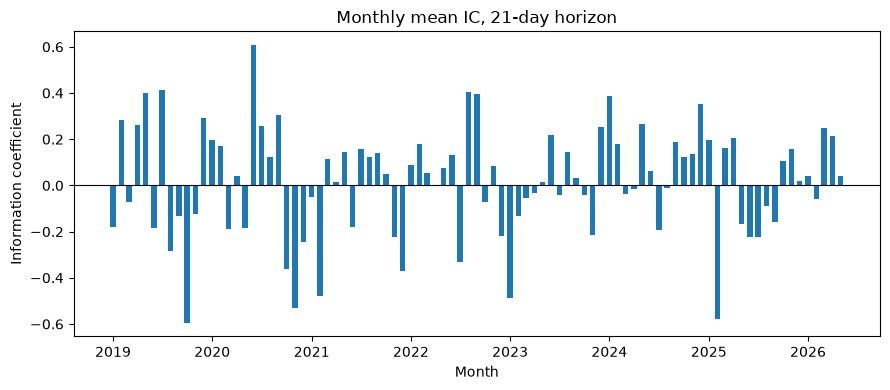

In [8]:
monthly_ic = panel.mean_ic(by="1mo").to_pandas()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(monthly_ic["bucket"], monthly_ic["ic_21"], width=20)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Monthly mean IC, 21-day horizon")
ax.set_xlabel("Month")
ax.set_ylabel("Information coefficient")
fig.tight_layout()

## 5. Quantile returns and the spread

The IC says the ranking is informative. The quantile table says whether the
information is in the part of the distribution you can trade, and the standard
errors say whether the difference between two buckets is a difference at all.

In [9]:
quantiles = panel.quantile_returns().to_pandas()
quantiles.round(5)

,factor_quantile,mean_1,stderr_1,mean_5,stderr_5,mean_21,stderr_21
0,1,0.00019,0.00020,0.00088,0.00043,0.00271,0.00086
1,2,-0.00026,0.00013,-0.00131,0.00030,-0.00310,0.00060
2,3,-0.00016,0.00011,-0.00042,0.00026,-0.00187,0.00055
3,4,-0.00004,0.00014,-0.00046,0.00030,-0.00239,0.00061
4,5,0.00027,0.00020,0.00130,0.00043,0.00465,0.00081


`spread` is the top bucket minus the bottom one, per date, with a joint
standard error. It is the closest thing in the panel to a tradeable series,
and it is still gross of every cost in section 04.

In [10]:
spread = panel.spread().to_pandas()
summary = {
    f"spread_{period}": {
        "mean": spread[f"spread_{period}"].mean(),
        "t-stat": spread[f"spread_{period}"].mean()
        / spread[f"spread_{period}"].std()
        * len(spread) ** 0.5,
    }
    for period in (1, 5, 21)
}
pd.DataFrame(summary).round(4)

,spread_1,spread_5,spread_21
mean,0.0001,0.0004,0.0019
t-stat,0.2227,0.5405,1.2913


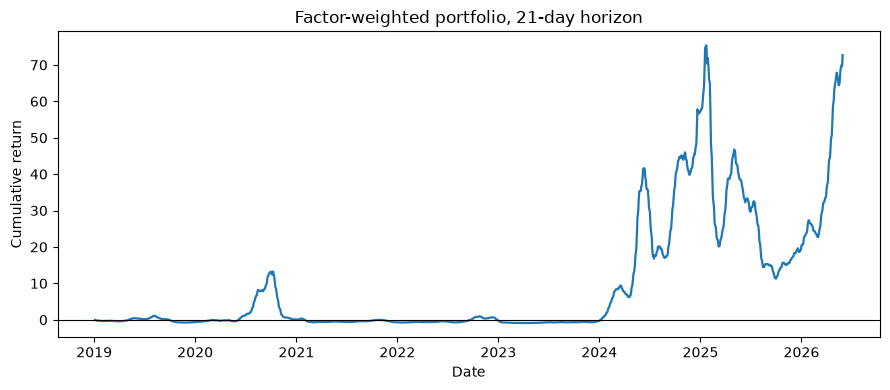

In [11]:
cumulative = panel.cumulative_returns(period=21).to_pandas()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cumulative["ts"], cumulative["cumulative_return"], linewidth=1.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Factor-weighted portfolio, 21-day horizon")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
fig.tight_layout()

`alpha_beta` regresses the factor portfolio against the equally weighted
universe, one row per horizon, so the question "is this just market exposure"
gets an answer rather than an argument.

In [12]:
pd.DataFrame(panel.alpha_beta()).round(4)

,period,alpha,ann_alpha,beta
0,1,0.0002,0.0501,-0.0115
1,5,0.0011,0.0561,-0.0638
2,21,0.0046,0.0565,-0.1024


## 6. What it costs to hold

Turnover and rank autocorrelation are the two numbers that decide whether an
IC survives contact with recipe 04/11. A factor whose top bucket changes
completely every day needs an enormous IC to pay for itself.

In [13]:
turnover = panel.turnover(period=1).to_pandas()
autocorrelation = panel.rank_autocorrelation(period=1).to_pandas()
print(f"mean daily turnover by bucket:")
print(turnover.groupby("factor_quantile")["turnover"].mean().round(4).to_string())
print(f"\nmean rank autocorrelation: {autocorrelation['autocorrelation'].mean():.4f}")
print(f"implied average holding period: "
      f"{1 / max(turnover['turnover'].mean(), 1e-9):.1f} days")

mean daily turnover by bucket:
factor_quantile
1    0.0626
2    0.1390
3    0.1543
4    0.1357
5    0.0579

mean rank autocorrelation: 0.9901
implied average holding period: 9.1 days


## 7. Sectors, and what neutrality changes

A momentum factor that loads on one sector is a sector bet with extra steps.
`group` accepts a mapping from asset to group; `by_group` scores each sector
separately, and `group_adjust` demeans the forward returns within a sector
before scoring, which is the question "does this work *within* a sector".

In [14]:
SECTORS = {
    "AAPL": "tech", "MSFT": "tech", "NVDA": "tech", "GOOGL": "tech", "META": "tech",
    "CSCO": "tech", "IBM": "tech", "V": "financials", "JPM": "financials",
    "BAC": "financials", "GS": "financials", "BRK-B": "financials",
    "XOM": "energy", "CVX": "energy", "UNH": "health", "JNJ": "health",
    "MRK": "health", "ABBV": "health", "PG": "staples", "PEP": "staples",
    "KO": "staples", "COST": "staples", "WMT": "staples", "AMZN": "discretionary",
    "HD": "discretionary", "MCD": "discretionary", "DIS": "discretionary",
    "CAT": "industrials", "GE": "industrials", "T": "telecom",
}
grouped = quant.build_panel(
    db,
    factor_frame,
    price_frame,
    periods=(1, 5, 21),
    quantiles=5,
    group=SECTORS,
    max_loss=0.35,
)
by_sector = grouped.mean_ic(by_group=True).to_pandas()
print(by_sector.round(4).to_string(index=False))

        group    ic_1    ic_5   ic_21
discretionary  0.0019 -0.0264 -0.0849
       energy -0.0382 -0.0639 -0.0392
   financials  0.0387  0.0264  0.0035
       health  0.0174  0.0256  0.0243
  industrials  0.0188  0.0134 -0.0005
      staples  0.0377  0.0571  0.0531
         tech  0.0107  0.0109  0.0285
      telecom     NaN     NaN     NaN


`telecom` has one member, and a group of one has no cross-section to rank, so
its IC is undefined rather than zero. That is the correct answer and a useful
reminder that group statistics inherit the group's size.

In [15]:
plain = grouped.mean_ic().to_pandas().iloc[0]
neutral = grouped.mean_ic(group_adjust=True).to_pandas().iloc[0]
pd.DataFrame({"raw": plain, "sector-neutral": neutral}).round(4)

,raw,sector-neutral
ic_1,0.0230,0.0096
ic_5,0.0227,0.0028
ic_21,0.0183,-0.0066


The answer here is uncomfortable and worth stating plainly: most of this
factor's information coefficient is a sector bet. Demeaning forward returns
within sectors cuts the one-day IC by more than half and turns the one-month
IC negative. A momentum book run against this universe would have been long
whichever sector had been running.

## 8. The report

`quant.factor_report` renders the same page `alphalens` prints, as a
self-contained HTML file with the provenance header attached.

In [16]:
html = quant.factor_report(panel, path="data/cache/momentum-factor-report.html")
payload = quant.report_payload(panel)
print(f"wrote {len(html):,} bytes")
print(f"tables {[table['id'] for table in payload.get('tables', [])]}")
print(f"charts {[chart['id'] for chart in payload.get('charts', [])]}")

wrote 705,904 bytes
tables ['decay-table', 'quantile-table']
charts ['ic', 'ic-decay', 'quantile-returns', 'turnover', 'autocorrelation', 'cumulative']


## 9. A panel is a query, not a result

Nothing above materialised the panel in Python. `frame` exposes it as a lazy
frame so a downstream query can filter, join or aggregate it inside the
engine, and `sql()` prints exactly what would run.

In [17]:
recent = (
    panel.frame.filter(col("ts") >= "2026-01-01")
    .group_by("factor_quantile")
    .agg(days=col("fwd_21").count(), mean_fwd_21=col("fwd_21").mean())
    .sort("factor_quantile")
)
print(f"panel SQL is {len(panel.sql()):,} characters; nothing was collected to get here")
recent.to_pandas().round(5)

panel SQL is 2,516 characters; nothing was collected to get here


,factor_quantile,days,mean_fwd_21
0,1,612,0.01234
1,2,612,-0.00365
2,3,612,0.02145
3,4,612,0.01988
4,5,612,0.02791


## Takeaways

- `build_panel` joins factor to forward returns and buckets once; everything
  else is a query against that one definition.
- Read `loss_report` before reading the IC. A factor scored on the rows that
  survived is not the factor you built.
- `ic_decay` gives horizon and t-statistic in one query, which is the
  difference between "there is a signal" and "there is a number".
- Turnover and rank autocorrelation decide whether an IC can pay for itself.
- `group` turns a sector bet into a testable claim, and `group_adjust` asks
  whether the factor works inside a sector at all.
- The panel is a pinned query. Nothing leaves the engine until an aggregate
  small enough to read comes back.

In [18]:
db.close()